In [24]:
import matplotlib.pyplot as plt
from keras.layers import Input, Rescaling, ReLU, Dense, Conv2D, Flatten, Dropout, BatchNormalization, MaxPooling2D, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, GlobalAveragePooling2D
from keras.utils import image_dataset_from_directory
from keras.models import Sequential
from keras.applications import MobileNetV2, mobilenet_v2
from keras.models import Model
from keras.optimizers import Adam

In [4]:
# 1. Load the Training Dataset (80%)
train_dataset = image_dataset_from_directory(
    directory='data/data',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=42,          # Must match the validation seed!
    validation_split=0.2,
    subset='training'
)

# 2. Load the Validation Dataset (20%)
val_dataset = image_dataset_from_directory(
    directory='data/data/',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,     # Keeps it consistent, though shuffling val data is optional
    seed=42,          # Must match the training seed!
    validation_split=0.2,
    subset='validation' # Changed to validation
)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [21]:
mobilenet_base=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
mobilenet_base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
inputs = Input(shape=(224, 224, 3))
x = mobilenet_v2.preprocess_input(inputs)

x = mobilenet_base(x, training=False)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation='softmax')(x)

In [28]:
mobilenet_model = Model(inputs=inputs, outputs=outputs)
mobilenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,316,869 (69.87 MB)

 Trainable params: 16,058,373 (61.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [29]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training MobileNetV2 Head...")
mobilenet_model.fit(train_dataset, validation_data=val_dataset, epochs=5)

Training MobileNetV2 Head...
Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 681ms/step - accuracy: 0.8101 - loss: 0.6193 - val_accuracy: 0.8737 - val_loss: 0.5276
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.9517 - loss: 0.1518 - val_accuracy: 0.8841 - val_loss: 0.3502
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.9789 - loss: 0.0777 - val_accuracy: 0.8980 - val_loss: 0.3139
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9925 - loss: 0.0393 - val_accuracy: 0.8899 - val_loss: 0.3105
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.9959 - loss: 0.0266 - val_accuracy: 0.8934 - val_loss: 0.3100


In [30]:
mobilenet_base.trainable = True
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5), # Low learning rate to protect features
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning entire MobileNetV2 network...")
mobilenet_model.fit(train_dataset, validation_data=val_dataset, epochs=5)


Fine-tuning entire MobileNetV2 network...
Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 996ms/step - accuracy: 0.8793 - loss: 0.3692 - val_accuracy: 0.8980 - val_loss: 0.3349
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 69s 236ms/step - accuracy: 0.9244 - loss: 0.2080 - val_accuracy: 0.9050 - val_loss: 0.3562
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.9467 - loss: 0.1587 - val_accuracy: 0.9073 - val_loss: 0.3731
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step - accuracy: 0.9574 - loss: 0.1218 - val_accuracy: 0.9061 - val_loss: 0.3720
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 237ms/step - accuracy: 0.9684 - loss: 0.0930 - val_accuracy: 0.9050 - val_loss: 0.3716


In [ ]:
import tensorflow as tf
import numpy as np

def make_mobilenet_gradcam_heatmap(img_array, model, pred_index=None):
    # 1. Grab the embedded sub-model layer
    base_layer = model.get_layer('mobilenetv2_1.00_224')

    # 2. Extract its final internal activation layer
    last_conv_layer = base_layer.get_layer('out_relu')

    # 3. Create a clean sub-model specifically for tracking features
    grad_model = tf.keras.models.Model(
        inputs=[base_layer.input],
        outputs=[last_conv_layer.output, base_layer.output]
    )

    # 4. Make sure our input image is preprocessed for MobileNetV2 explicitly
    processed_img = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # 5. Track gradients on the sub-model ONLY
    with tf.GradientTape() as tape:
        last_conv_layer_output, base_predictions = grad_model(processed_img)

        # If no prediction index is specified, use the top predicted index from our main model
        if pred_index is None:
            outer_preds = model(img_array)
            pred_index = tf.argmax(outer_preds[0])

        # Route to the feature space output from the base sub-model mapping
        class_channel = base_predictions[:, pred_index]

    # 6. Compute gradients safely (No more None values!)
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Compute the weighted activation map
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Normalize output
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [35]:
import cv2
import numpy as np

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Convert heatmap to a color jet map (Red = Hot, Blue = Cold)
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    jet = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    jet = cv2.resize(jet, (img.shape[1], img.shape[0]))

    # Superimpose the images
    superimposed_img = jet * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    return superimposed_img

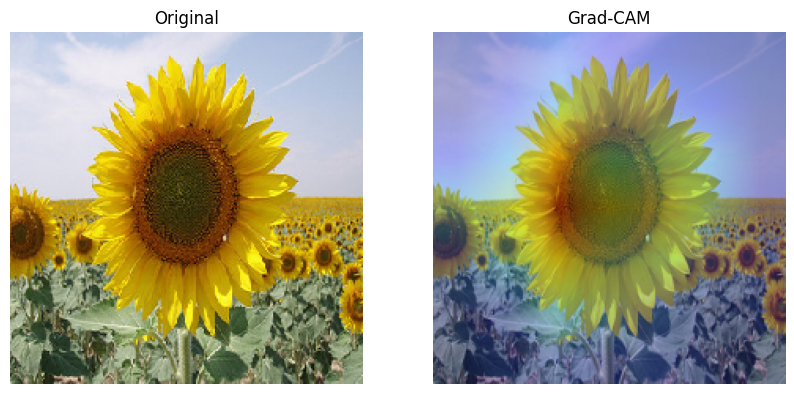

In [ ]:
import matplotlib.pyplot as plt

# 1. Provide a path to any test flower image on our machine
sample_img_path = "data/sunflower/1022552002_2b93faf9e7_n.jpg"

# 2. Prepare the image array structure that TensorFlow expects
img = tf.keras.utils.load_img(sample_img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Reshapes to (1, 224, 224, 3)

# 3. Generate the heatmap using our new function
# Assumes our trained model variable name is 'mobilenet_model'
mobilenet_heatmap = make_mobilenet_gradcam_heatmap(img_array, mobilenet_model)
gradcam_result = display_gradcam(sample_img_path, mobilenet_heatmap)

# Show the plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img); plt.axis("off"); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(gradcam_result); plt.axis("off"); plt.title("Grad-CAM")
plt.show()

### Observation
Looking closely at our heatmap, you can see exactly how intelligent MobileNetV2 is behaving:

The Focal Point: The red and orange "hot spots" are localized right at the transition boundary between the bright yellow petals and the dark, textured center disk seed-bed. This tells you the model isn't just randomly guessing based on color; it is actively using the structural features of a sunflower to make its decision.

Background Rejection: Notice how the blue and purple tones cover the sky, the green leaves below, and the other blurred sunflowers in the field. The model completely ignores the background context, proving that it isn't "cheating." It is focusing purely on the main subject.